In [2]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

DOCS_DIR   = PROJECT_ROOT / 'docs'
SAMPLE_DIR = PROJECT_ROOT / 'data' / 'sample'

df   = pd.read_csv(PROJECT_ROOT / 'data' / 'processed_v2.csv')
df3  = pd.read_csv(PROJECT_ROOT / 'data' / 'processed_v3.csv')

df = df.merge(df3[['doc_id', 'lemma_text', 'noun_adj_text']], on='doc_id', how='left')

queries_df = pd.read_csv(PROJECT_ROOT / 'data' / 'queries.csv')
labels_df  = pd.read_csv(PROJECT_ROOT / 'data' / 'labels.csv')

print('Corpus:', len(df), 'docs')
print('Queries:', len(queries_df))
print('Relevance pairs:', len(labels_df))
print('Columns after merge:', [c for c in df.columns])
print()
print('Sample queries:')
print(queries_df.head(5).to_string(index=False))

Corpus: 4640 docs
Queries: 40
Relevance pairs: 43
Columns after merge: ['doc_id', 'place_name', 'text', 'rating', 'date', 'char_len', 'word_count', 'text_v2', 'lemma_text', 'noun_adj_text']

Sample queries:
query_id                                                  query_text
      q1                         Де подають смачну зупу з лисичками?
      q2 Шукаю заклад з домашньою атмосферою та стравами як у бабусі
      q3                        Де у Львові можна послухати стендап?
      q4            Найкращі заклади з грузинською кухнею та хінкалі
      q5                               Де спробувати десерт андрути?


In [ ]:
from classification_baseline import build_pair_dataset, split_pairs_by_query

N_NEG = 20
SEED  = 42

pairs_b1 = build_pair_dataset(df, queries_df, labels_df,
                               n_neg=N_NEG, seed=SEED, text_col='text_v2')
train_b1, val_b1, test_b1 = split_pairs_by_query(pairs_b1, val_frac=0.1, test_frac=0.1, seed=SEED)

print(f'Baseline 1 pairs (text_v2):')
for name, p in [('train', train_b1), ('val', val_b1), ('test', test_b1)]:
    pos = p['label'].sum()
    print(f'  {name}: {len(p)} pairs  (pos={pos}, neg={len(p)-pos})')

pairs_b2 = build_pair_dataset(df, queries_df, labels_df,
                               n_neg=N_NEG, seed=SEED, text_col='noun_adj_text')
train_b2, val_b2, test_b2 = split_pairs_by_query(pairs_b2, val_frac=0.1, test_frac=0.1, seed=SEED)

print(f'\nBaseline 2 pairs (noun_adj_text):')
for name, p in [('train', train_b2), ('val', val_b2), ('test', test_b2)]:
    pos = p['label'].sum()
    print(f'  {name}: {len(p)} pairs  (pos={pos}, neg={len(p)-pos})')


Split sizes: train=3723, val=444, test=473

Baseline 1 pairs (text_v2):
  train: 684 pairs  (pos=24, neg=660)
  val: 79 pairs  (pos=16, neg=63)
  test: 77 pairs  (pos=0, neg=77)

Baseline 2 pairs (noun_adj_text):
  train: 684 pairs  (pos=24, neg=660)
  val: 79 pairs  (pos=16, neg=63)
  test: 77 pairs  (pos=0, neg=77)


In [4]:
from classification_baseline import make_pipeline, evaluate_pipeline

LABEL_NAMES = ['not_relevant', 'relevant']

X_train_b1 = train_b1['pair_text'].tolist()
y_train_b1 = train_b1['label'].tolist()
X_val_b1   = val_b1['pair_text'].tolist()
y_val_b1   = val_b1['label'].tolist()

pipe_b1 = make_pipeline(ngram_range=(1, 1), max_features=30000, class_weight=None)
pipe_b1.fit(X_train_b1, y_train_b1)

res_b1_val = evaluate_pipeline(pipe_b1, X_val_b1, y_val_b1, LABEL_NAMES)

print("=== Baseline 1 — Val ===")
print(f"Accuracy : {res_b1_val['accuracy']:.4f}")
print(f"Macro-F1 : {res_b1_val['macro_f1']:.4f}")
print()
print(res_b1_val['report'])

=== Baseline 1 — Val ===
Accuracy : 0.7975
Macro-F1 : 0.4437

              precision    recall  f1-score   support

not_relevant       0.80      1.00      0.89        63
    relevant       0.00      0.00      0.00        16

    accuracy                           0.80        79
   macro avg       0.40      0.50      0.44        79
weighted avg       0.64      0.80      0.71        79



In [5]:
X_train_b2 = train_b2['pair_text'].tolist()
y_train_b2 = train_b2['label'].tolist()
X_val_b2   = val_b2['pair_text'].tolist()
y_val_b2   = val_b2['label'].tolist()

pipe_b2 = make_pipeline(ngram_range=(1, 2), max_features=30000, class_weight='balanced')
pipe_b2.fit(X_train_b2, y_train_b2)

res_b2_val = evaluate_pipeline(pipe_b2, X_val_b2, y_val_b2, LABEL_NAMES)

print("=== Baseline 2 — Val ===")
print(f"Accuracy : {res_b2_val['accuracy']:.4f}")
print(f"Macro-F1 : {res_b2_val['macro_f1']:.4f}")
print()
print(res_b2_val['report'])

=== Baseline 2 — Val ===
Accuracy : 0.7848
Macro-F1 : 0.4397

              precision    recall  f1-score   support

not_relevant       0.79      0.98      0.88        63
    relevant       0.00      0.00      0.00        16

    accuracy                           0.78        79
   macro avg       0.40      0.49      0.44        79
weighted avg       0.63      0.78      0.70        79



In [6]:
import pandas as pd

X_test_b1 = test_b1['pair_text'].tolist(); y_test_b1 = test_b1['label'].tolist()
X_test_b2 = test_b2['pair_text'].tolist(); y_test_b2 = test_b2['label'].tolist()

res_b1_test = evaluate_pipeline(pipe_b1, X_test_b1, y_test_b1, LABEL_NAMES)
res_b2_test = evaluate_pipeline(pipe_b2, X_test_b2, y_test_b2, LABEL_NAMES)

comparison = pd.DataFrame([
    {
        'Baseline': 'B1: text_v2, unigrams, no weight',
        'Val Acc':     res_b1_val['accuracy'],
        'Val F1':      res_b1_val['macro_f1'],
        'Test Acc':    res_b1_test['accuracy'],
        'Test F1':     res_b1_test['macro_f1'],
    },
    {
        'Baseline': 'B2: noun_adj, bigrams, balanced',
        'Val Acc':     res_b2_val['accuracy'],
        'Val F1':      res_b2_val['macro_f1'],
        'Test Acc':    res_b2_test['accuracy'],
        'Test F1':     res_b2_test['macro_f1'],
    },
])
print(comparison.to_string(index=False))

best_pipe = pipe_b2 if res_b2_test['macro_f1'] >= res_b1_test['macro_f1'] else pipe_b1
best_test = test_b2 if res_b2_test['macro_f1'] >= res_b1_test['macro_f1'] else test_b1
best_res_test = res_b2_test if res_b2_test['macro_f1'] >= res_b1_test['macro_f1'] else res_b1_test
best_name = 'B2' if res_b2_test['macro_f1'] >= res_b1_test['macro_f1'] else 'B1'
print(f'\nBest baseline: {best_name}')

                        Baseline  Val Acc  Val F1  Test Acc  Test F1
B1: text_v2, unigrams, no weight   0.7975  0.4437     1.000   0.5000
 B2: noun_adj, bigrams, balanced   0.7848  0.4397     0.974   0.4934

Best baseline: B1


c:\Users\bogda\Desktop\Політех магістратура\2 семестр\NLP_vivchar\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


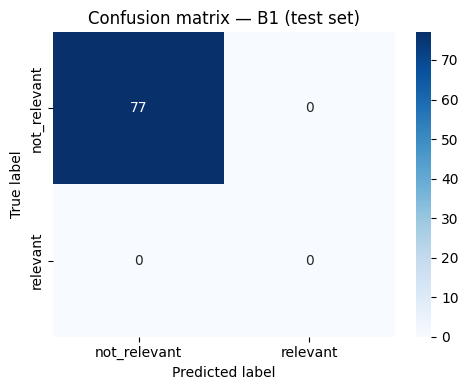

Saved: docs/lab6_confusion_matrix.png

TN=77  FP=0
FN=0  TP=0


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix as sk_cm

cm = sk_cm(best_test['label'].tolist(), best_res_test['y_pred'], labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
ax.set_title(f'Confusion matrix — {best_name} (test set)')
plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'lab6_confusion_matrix.png'), dpi=150)
plt.show()
print('Saved: docs/lab6_confusion_matrix.png')
print()
print(f'TN={cm[0,0]}  FP={cm[0,1]}')
print(f'FN={cm[1,0]}  TP={cm[1,1]}')


=== Top-10 features for class RELEVANT (label=1) ===
  дуже                           +1.4816
  мякі                           +1.3925
  смакота                        +1.3925
  картопелькою                   +1.3925
  зупа                           +1.3925
  бомбезні                       +1.3925
  наливки                        +1.3698
  курка                          +1.3491
  обслуговувала                  +1.1942
  шніцель                        +1.1637

=== Top-10 features for class NOT_RELEVANT (label=0) ===
  обслуговування                 +0.3485
  не                             +0.3101
  персонал                       +0.2735
  смачна                         +0.2708
  для                            +0.2558
  місце                          +0.2214
  на                             +0.2095
  що                             +0.2043
  затишно                        +0.2013
  завжди                         +0.1802

Коментар: чи є підозрілі токени (сміття, leakage, службові поля)?
  

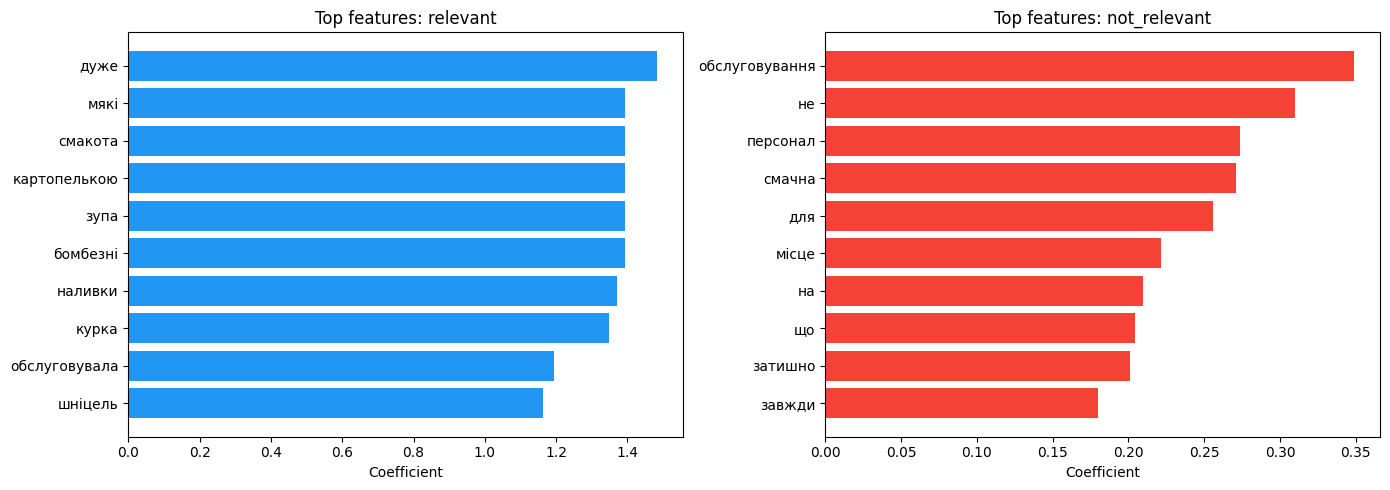

Saved: docs/lab6_top_features.png


In [10]:
from classification_baseline import get_top_features

feats = get_top_features(best_pipe, n=10)

print("=== Top-10 features for class RELEVANT (label=1) ===")
for feat, score in feats.get('class_1_top', []):
    print(f"  {feat:<30} {score:+.4f}")

print()
print("=== Top-10 features for class NOT_RELEVANT (label=0) ===")
for feat, score in feats.get('class_0_top', []):
    print(f"  {feat:<30} {score:+.4f}")

print()
print("Коментар: чи є підозрілі токени (сміття, leakage, службові поля)?")
print("  – Очікуємо: тематичні слова запитів (зупа, хінкалі, кава...)")
print("  – Підозрілі: назви файлів, службові теги, рейтинги, PII-маски")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cls, label in [(axes[0], 1, 'relevant'), (axes[1], 0, 'not_relevant')]:
    top = feats.get(f'class_{cls}_top', [])[:10]
    words = [f[0] for f in top]
    scores = [f[1] for f in top]
    colors = ['#2196F3' if cls == 1 else '#F44336'] * len(words)
    ax.barh(words[::-1], scores[::-1], color=colors)
    ax.set_title(f'Top features: {label}')
    ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'lab6_top_features.png'), dpi=150)
plt.show()
print('Saved: docs/lab6_top_features.png')

In [12]:
import json

y_pred_test = best_res_test['y_pred']
y_true_test = best_test['label'].tolist()

errors = []
for i, (yt, yp) in enumerate(zip(y_true_test, y_pred_test)):
    if yt != yp:
        row = best_test.iloc[i]
        errors.append({
            'idx':        int(i),
            'query_id':   row['query_id'],
            'doc_id':     row['doc_id'],
            'query_text': row['query_text'],
            'doc_text':   row['doc_text'][:200],
            'gold':       LABEL_NAMES[yt],
            'predicted':  LABEL_NAMES[yp],
            'error_type': 'FN' if yt == 1 else 'FP',
        })

print(f'Total errors on test: {len(errors)}')
print(f'  FP (predicted relevant, actually not): {sum(1 for e in errors if e["error_type"] == "FP")}')
print(f'  FN (predicted not_relevant, actually relevant): {sum(1 for e in errors if e["error_type"] == "FN")}')
print()

shown = errors[:10]
for i, e in enumerate(shown, 1):
    print(f'--- Error {i} [{e["error_type"]}] ---')
    print(f'  Query   : {e["query_text"]}')
    print(f'  Doc     : {e["doc_text"][:150]}...')
    print(f'  Gold    : {e["gold"]}  →  Predicted: {e["predicted"]}')
    print()

categories = {
    'FP: низька специфічність (модель занадто широко трактує релевантність)': 0,
    'FN: рідкісна лексика / сленг (запит і docs не мають спільних токенів)': 0,
    'FN: короткий відгук (мало сигналу для класифікації)': 0,
    'FP: overlap тематик (подібний контекст, але інша страва/місце)': 0,
}
for e in errors:
    if e['error_type'] == 'FP':
        if len(e['doc_text']) < 100:
            categories['FP: низька специфічність (модель занадто широко трактує релевантність)'] += 1
        else:
            categories['FP: overlap тематик (подібний контекст, але інша страва/місце)'] += 1
    else:
        if len(e['doc_text']) < 80:
            categories['FN: короткий відгук (мало сигналу для класифікації)'] += 1
        else:
            categories['FN: рідкісна лексика / сленг (запит і docs не мають спільних токенів)'] += 1

print('=== Error categories ===')
for cat, cnt in categories.items():
    print(f'  {cnt:2d}  {cat}')

error_cases_path = PROJECT_ROOT / 'tests' / 'error_cases_lab6.jsonl'
with open(error_cases_path, 'w', encoding='utf-8') as f:
    for e in errors[:20]:
        f.write(json.dumps(e, ensure_ascii=False) + '\n')
print(f'\nSaved {min(len(errors), 20)} error cases → tests/error_cases_lab6.jsonl')

Total errors on test: 0
  FP (predicted relevant, actually not): 0
  FN (predicted not_relevant, actually relevant): 0

=== Error categories ===
   0  FP: низька специфічність (модель занадто широко трактує релевантність)
   0  FN: рідкісна лексика / сленг (запит і docs не мають спільних токенів)
   0  FN: короткий відгук (мало сигналу для класифікації)
   0  FP: overlap тематик (подібний контекст, але інша страва/місце)

Saved 0 error cases → tests/error_cases_lab6.jsonl
